In [1]:
import os
os.chdir(r"C:/Users/PREM/OneDrive/Desktop/Internship_Project/processed/")

In [2]:
import pandas as pd

In [3]:
df = pd.read_excel('cleaned_dataset.xlsx')
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,ORD201194,2023-11-19,C29885,Printer,3,189.44,725 Main St,Cash,Pending,TRK62067865,4,FREESHIP,Email,568.32
882,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
883,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
884,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,886,2024-03-25 23:01:29.390519296,2023-01-01 00:00:00,2023-08-17 00:00:00,2024-03-23 12:00:00,2024-11-10 00:00:00,2025-06-30 00:00:00,NaN
Quantity,886.0,2.910835,1.0,2.0,3.0,4.0,5.0,1.414995
UnitPrice,886.0,361.491896,11.39,190.2425,372.415,526.9525,699.93,196.372621
ItemsInCart,886.0,5.454853,1.0,4.0,5.0,7.0,10.0,2.276307
TotalPrice,886.0,1059.609808,11.39,418.3525,823.065,1582.7775,3456.4,822.124866


In [6]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print('Numeric Summary Statistics :\n')
summary

Numeric Summary Statistics :



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Quantity,886.0,2.910835,1.414995,1.00,2.0000,3.000,4.0000,5.00,3.000,2.000,0.050213
UnitPrice,886.0,361.491896,196.372621,11.39,190.2425,372.415,526.9525,699.93,372.415,336.710,-0.031503
ItemsInCart,886.0,5.454853,2.276307,1.00,4.0000,5.000,7.0000,10.00,5.000,3.000,-0.026292
TotalPrice,886.0,1059.609808,822.124866,11.39,418.3525,823.065,1582.7775,3456.40,823.065,1164.425,0.905707


In [7]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 6 outliers


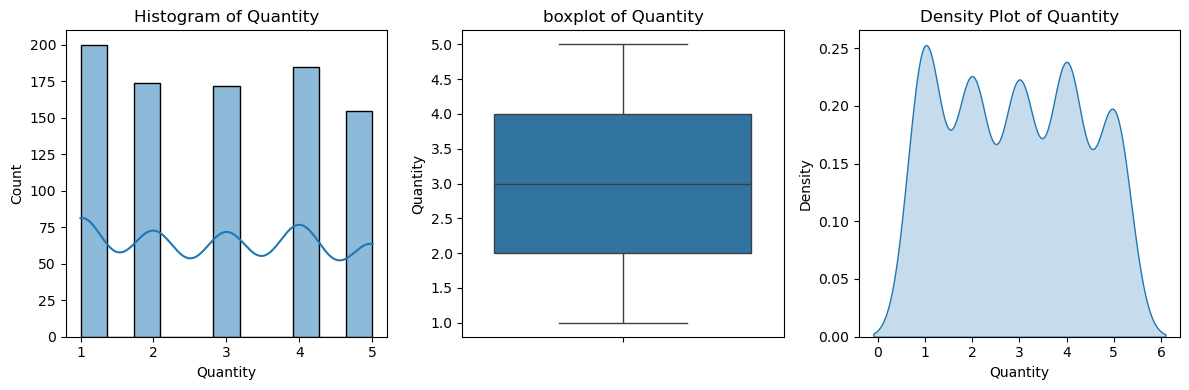

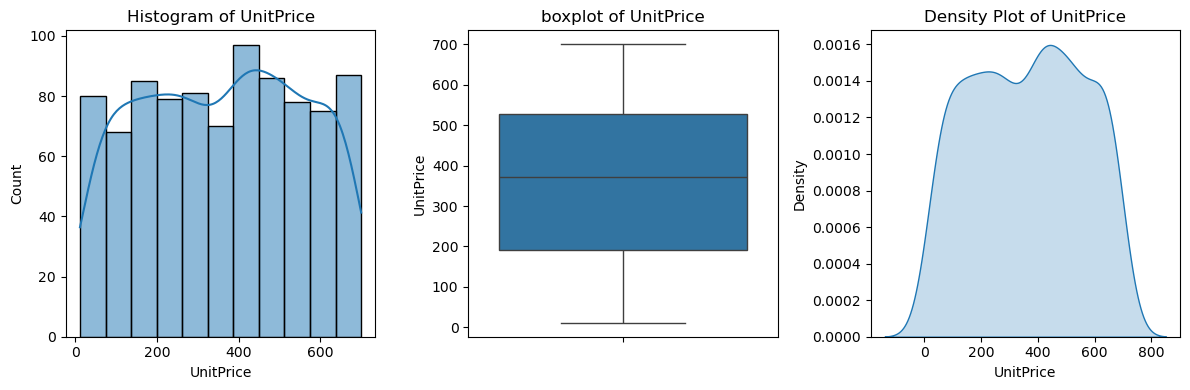

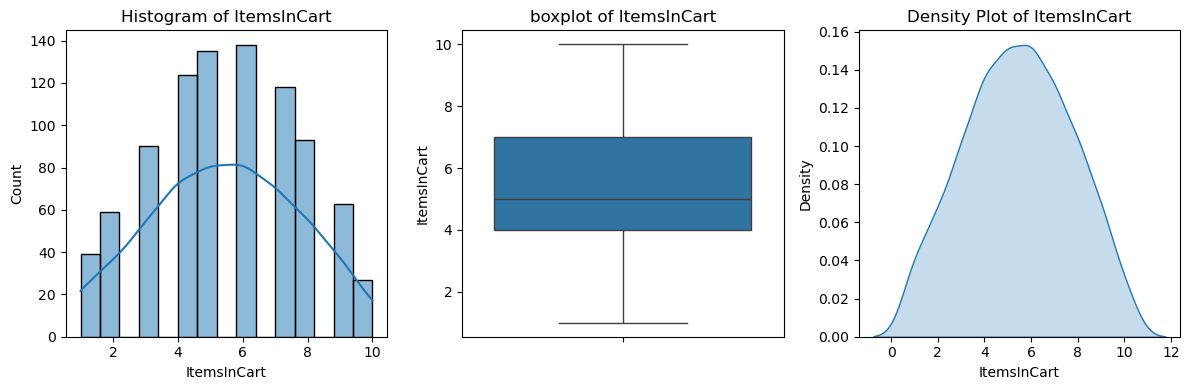

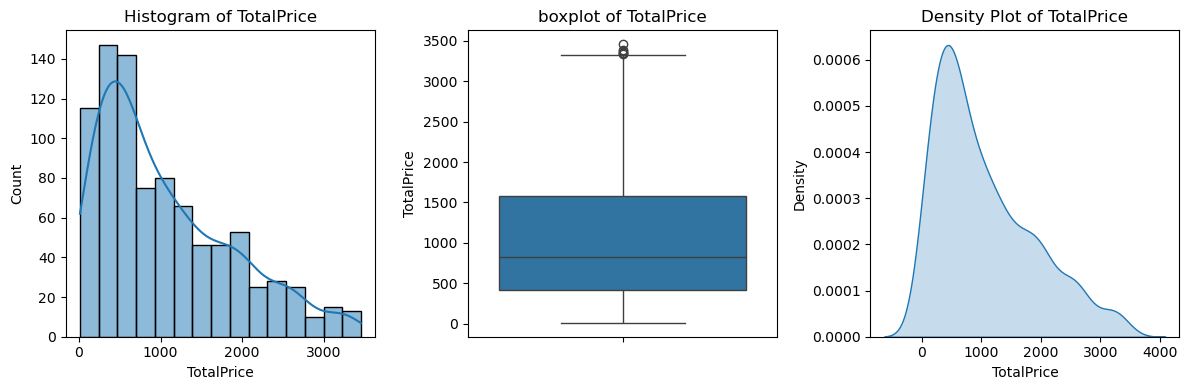

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=df[col])
    plt.title(f'boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col],fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()


Frequency Count For Product:

Product
Printer    137
Tablet     132
Chair      130
Desk       129
Laptop     127
Phone      116
Monitor    115
Name: count, dtype: int64


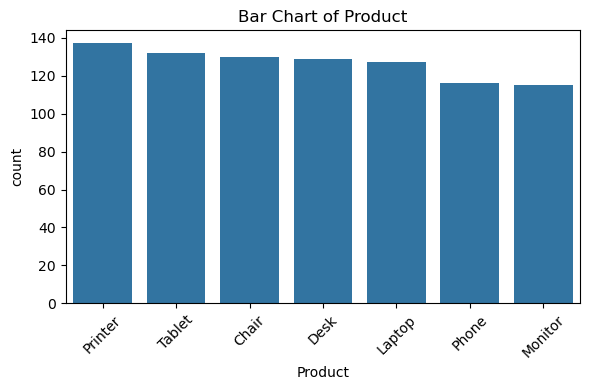


Frequency Count For PaymentMethod:

PaymentMethod
Cash           182
Gift Card      180
Credit Card    179
Online         178
Debit Card     167
Name: count, dtype: int64


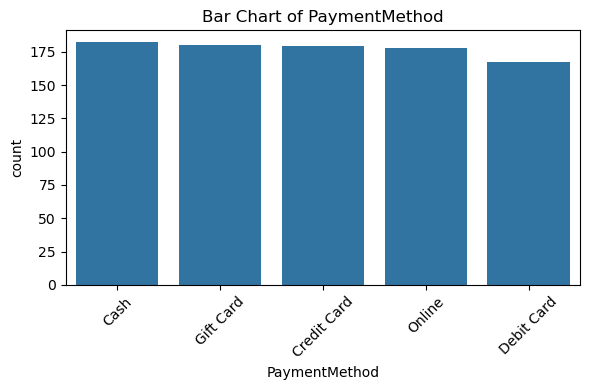


Frequency Count For OrderStatus:

OrderStatus
Cancelled    191
Delivered    178
Pending      175
Shipped      171
Returned     171
Name: count, dtype: int64


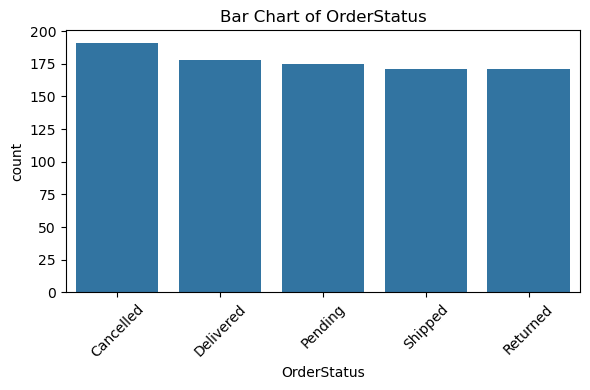


Frequency Count For CouponCode:

CouponCode
FREESHIP    310
WINTER15    291
SAVE10      285
Name: count, dtype: int64


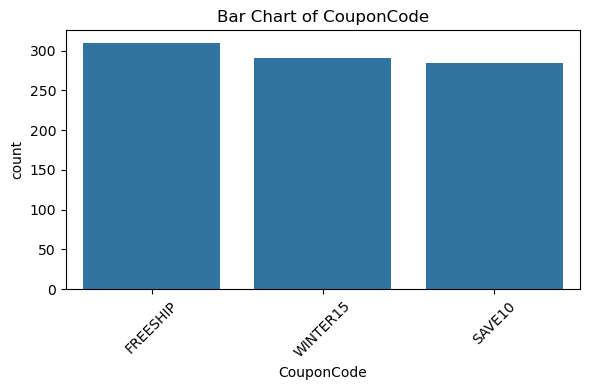


Frequency Count For ReferralSource:

ReferralSource
Instagram    198
Email        193
Google       175
Referral     161
Facebook     159
Name: count, dtype: int64


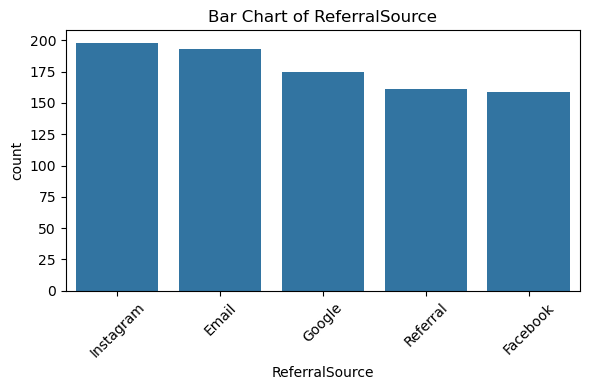

In [9]:
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

for col in cat_cols:
    print(f"\nFrequency Count For {col}:\n")
    print(df[col].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          886 non-null    object        
 1   Date             886 non-null    datetime64[ns]
 2   CustomerID       886 non-null    object        
 3   Product          886 non-null    object        
 4   Quantity         886 non-null    int64         
 5   UnitPrice        886 non-null    float64       
 6   ShippingAddress  886 non-null    object        
 7   PaymentMethod    886 non-null    object        
 8   OrderStatus      886 non-null    object        
 9   TrackingNumber   886 non-null    object        
 10  ItemsInCart      886 non-null    int64         
 11  CouponCode       886 non-null    object        
 12  ReferralSource   886 non-null    object        
 13  TotalPrice       886 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)


 Date Range For Date: 2023-01-01 00:00:00 to 2025-06-30 00:00:00
Time span : 911 days


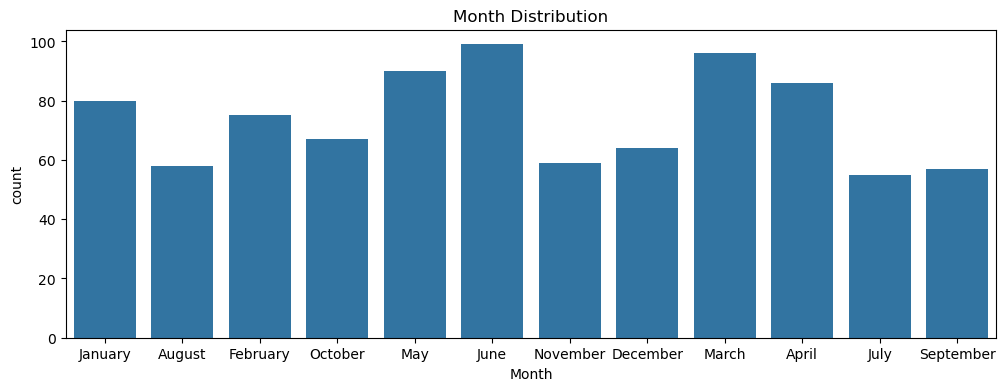

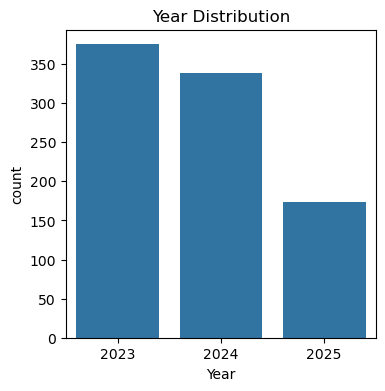

In [11]:
date_cols = ['Date']

for col in date_cols:
    print(f'\n Date Range For {col}: {df[col].min()} to {df[col].max()}')
    print(f'Time span : {(df[col].max() - df[col].min()).days} days')

    plt.figure(figsize=(12,4))
    df['Month'] = df['Date'].dt.month_name()
    sns.countplot(x='Month', data=df)
    plt.title('Month Distribution')
    plt.show()

    plt.figure(figsize=(4,4))
    df['Year'] = df['Date'].dt.year
    sns.countplot(x='Year', data=df)
    plt.title('Year Distribution')
    plt.show()

In [12]:
def time_granularity(series):
    diffs = series.sort_values().diff().dropna().dt.days
    return diffs.describe()

In [13]:
time_granularity(df['Date'])

count    885.000000
mean       1.029379
std        1.068490
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: Date, dtype: float64

In [14]:
df['Date'].sort_values().diff().value_counts()

Date
1 days    343
0 days    316
2 days    149
3 days     52
4 days     17
6 days      4
5 days      3
7 days      1
Name: count, dtype: int64

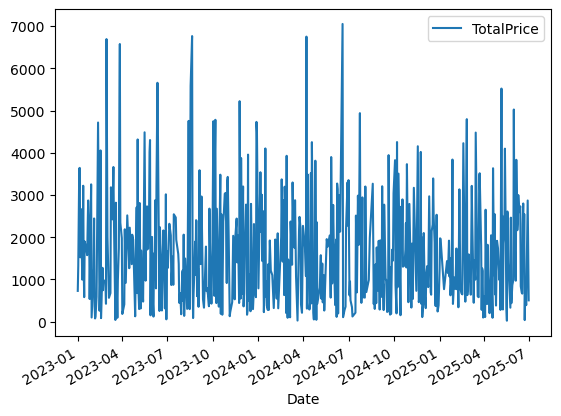

In [15]:
df.groupby('Date')[['TotalPrice']].sum().plot()
plt.show()

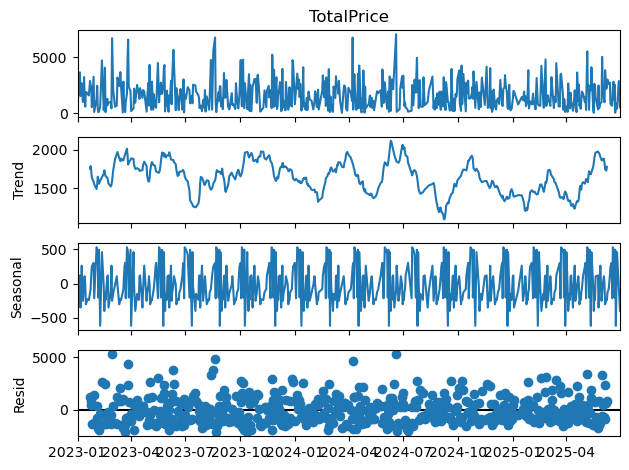

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_daily = df.groupby('Date')['TotalPrice'].sum()
result = seasonal_decompose(df_daily, model='additive', period=30)

fig = result.plot()
plt.show()

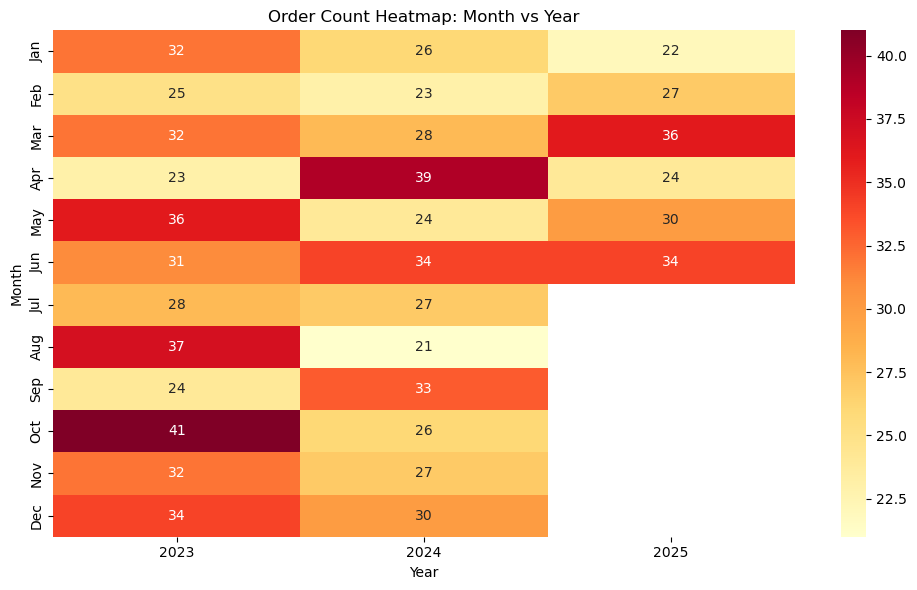

In [17]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

pivot = df.pivot_table(index='Month', columns='Year', values='OrderID', aggfunc='count')

pivot.index = pd.to_datetime(pivot.index, format='%m').strftime('%b')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Order Count Heatmap: Month vs Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

In [18]:
df[numeric_cols].corr().round(2)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.00,0.03,0.64,0.64
UnitPrice,0.03,1.00,0.02,0.71
ItemsInCart,0.64,0.02,1.00,0.41
TotalPrice,0.64,0.71,0.41,1.00
